# P4-P5 local reproducible notebook

This notebook reproduces the P4-P5 analysis from the raw files in `Data_raw`.
It is designed to be run on your own computer in Jupyter Notebook or JupyterLab.

What it reproduces:

- P4 DESNZ current-policy annual baseline, excluding and including IAS.
- P4 official CB4-CB6 carbon-budget gap metrics.
- P5 CCC7 Balanced Pathway and CCC6 Balanced Net Zero Pathway benchmarks.
- DESNZ vs CCC annual benchmark-year gaps.
- Carbon-budget-period benchmark sums.
- Clean CSV outputs and two figures.

Important: run cells from top to bottom. Do not manually type headline numbers; the notebook calculates them from the source workbooks.


## 0. Install dependencies if needed

Run the next cell only if your Jupyter environment is missing packages. If imports already work, leave it commented.


In [1]:
# Run this cell only if imports fail.
# %pip install pandas openpyxl odfpy matplotlib numpy


## 1. Setup and project-root detection

The notebook tries to find your dissertation folder by looking for a `Data_raw` folder. If it cannot find it, set `MANUAL_PROJECT_ROOT` to your local path.


In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If auto-detection fails, uncomment and edit this line:
# MANUAL_PROJECT_ROOT = Path(r"E:\UCL Final Essay")
MANUAL_PROJECT_ROOT = None


def locate_project_root():
    if MANUAL_PROJECT_ROOT is not None:
        root = Path(MANUAL_PROJECT_ROOT).expanduser().resolve()
        if not (root / "Data_raw").exists():
            raise FileNotFoundError(f"Manual project root does not contain Data_raw: {root}")
        return root

    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for candidate in candidates:
        if (candidate / "Data_raw").exists():
            return candidate

    fallback = Path(r"E:\UCL Final Essay")
    if (fallback / "Data_raw").exists():
        return fallback

    raise FileNotFoundError(
        "Cannot find Data_raw. Set MANUAL_PROJECT_ROOT to your dissertation folder."
    )


PROJECT_ROOT = locate_project_root()
RAW = PROJECT_ROOT / "Data_raw"
OUTPUT = PROJECT_ROOT / "p4_p5_local_reproduction"

for folder in [
    OUTPUT,
    OUTPUT / "data_inventory",
    OUTPUT / "data_processed",
    OUTPUT / "tables",
    OUTPUT / "figures",
]:
    folder.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW)
print("Output folder:", OUTPUT)


Project root: E:\UCL Final Essay
Raw data folder: E:\UCL Final Essay\Data_raw
Output folder: E:\UCL Final Essay\p4_p5_local_reproduction


## 2. Helper functions

These functions only handle text cleaning, file finding, spreadsheet reading, and table saving.


In [3]:
def show(obj, rows=8):
    """Display dataframes in Jupyter, print in plain Python."""
    try:
        display(obj)
    except NameError:
        if isinstance(obj, pd.DataFrame):
            print(obj.head(rows).to_string(index=False))
        else:
            print(obj)


def clean_text(value):
    """Normalize labels from Excel/ODS cells."""
    if pd.isna(value):
        return ""
    text = str(value)
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.replace("<text:s/>", " ")
    return re.sub(r"\s+", " ", text).strip()


def find_data_file(filename, preferred_contains=None):
    """Find a source file under Data_raw, preferring an official folder when duplicates exist."""
    matches = sorted(RAW.rglob(filename), key=lambda p: len(str(p)))
    if preferred_contains:
        preferred = [p for p in matches if preferred_contains.lower() in str(p).lower()]
        if preferred:
            return preferred[0]
    if not matches:
        raise FileNotFoundError(f"Could not find {filename} under {RAW}")
    return matches[0]


def read_ods(path, sheet_name, header=None):
    """Read an ODS sheet using pandas and odfpy."""
    try:
        return pd.read_excel(path, sheet_name=sheet_name, header=header, engine="odf")
    except ImportError as exc:
        raise ImportError("Reading .ods files requires odfpy. Run: %pip install odfpy") from exc


def year_columns(df, first_year=1990, last_year=2050):
    """Return a mapping {year: column_name} for year-labelled columns."""
    out = {}
    for col in df.columns:
        try:
            year = int(float(col))
        except (TypeError, ValueError):
            continue
        if first_year <= year <= last_year:
            out[year] = col
    return out


def extract_series_by_label_and_coverage(df, label, coverage):
    """Extract a wide annual series from DESNZ Annex A style tables."""
    label_col, coverage_col = df.columns[0], df.columns[1]
    mask = (
        df[label_col].map(clean_text).eq(label)
        & df[coverage_col].map(clean_text).eq(coverage)
    )
    if mask.sum() != 1:
        matches = df.loc[mask, [label_col, coverage_col]].to_string(index=False)
        raise ValueError(
            f"Expected one row for {label!r} / {coverage!r}, found {mask.sum()}\n{matches}"
        )
    row = df.loc[mask].iloc[0]
    cols = year_columns(df)
    series = pd.Series({year: pd.to_numeric(row[col], errors="coerce") for year, col in cols.items()})
    series.index.name = "year"
    series.name = coverage
    return series.sort_index()


def save_csv(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved {path}")


def safe_relative(path):
    try:
        return str(Path(path).relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)


def safe_sum_for_years(series, years):
    years = list(years)
    available = set(series.index.astype(int))
    if not set(years).issubset(available):
        return np.nan
    return float(series.loc[years].sum())


## 3. Locate source files

The notebook searches within `Data_raw`, so it can handle small folder-name differences. If there are duplicate files, it prefers the official DESNZ and CCC folders.


In [4]:
DESNZ_ANNEX_TES = find_data_file(
    "Annex_A_GHG_by_TES_sector.ods",
    preferred_contains="DESNZ Energy and Emissions Projections",
)
DESNZ_WEB_FIGURES = find_data_file(
    "Web_figures_EEP_2024_2050.ods",
    preferred_contains="DESNZ Energy and Emissions Projections",
)
DESNZ_WEB_TABLES = find_data_file(
    "Web_tables_EEP_2024_2050.ods",
    preferred_contains="DESNZ Energy and Emissions Projections",
)
CCC7_DATA = find_data_file(
    "The-Seventh-Carbon-Budget-full-dataset.xlsx",
    preferred_contains="CCC Seventh Carbon Budget",
)
CCC6_DATA = find_data_file(
    "The-Sixth-Carbon-Budget-Dataset_v2.xlsx",
    preferred_contains="CCC Sixth Carbon Budget",
)
UK_FINAL_GHG_TABLES = find_data_file(
    "final-greenhouse-gas-emissions-tables-2023.xlsx",
    preferred_contains="Final UK greenhouse gas emissions",
)

source_files = pd.DataFrame([
    ["DESNZ Annex A TES sectors", DESNZ_ANNEX_TES],
    ["DESNZ web figures", DESNZ_WEB_FIGURES],
    ["DESNZ web tables", DESNZ_WEB_TABLES],
    ["CCC Seventh Carbon Budget dataset", CCC7_DATA],
    ["CCC Sixth Carbon Budget dataset", CCC6_DATA],
    ["UK final GHG emissions tables 2023", UK_FINAL_GHG_TABLES],
], columns=["role", "path"])

show(source_files)


,role,path
0,DESNZ Annex A TES sectors,E:\UCL Final Essay\Data_raw\DESNZ Energy and E...
1,DESNZ web figures,E:\UCL Final Essay\Data_raw\DESNZ Energy and E...
2,DESNZ web tables,E:\UCL Final Essay\Data_raw\DESNZ Energy and E...
3,CCC Seventh Carbon Budget dataset,E:\UCL Final Essay\Data_raw\CCC Seventh Carbon...
4,CCC Sixth Carbon Budget dataset,E:\UCL Final Essay\Data_raw\CCC Sixth Carbon B...
5,UK final GHG emissions tables 2023,E:\UCL Final Essay\Data_raw\Final UK greenhous...


## 4. P4 - DESNZ annual baseline

This extracts the DESNZ EEP 2024 total GHG pathway excluding and including international aviation and shipping (IAS).


In [5]:
tes = read_ods(DESNZ_ANNEX_TES, sheet_name="Reference", header=2)

# Show labels near the top of the sheet so you can verify the row structure.
show(tes[[tes.columns[0], tes.columns[1], tes.columns[2]]].head(8))

desnz_excl_ias = extract_series_by_label_and_coverage(
    tes,
    label="GHG (All)",
    coverage="Total emissions (exc. IAS)",
)
desnz_inc_ias = extract_series_by_label_and_coverage(
    tes,
    label="GHG (All)",
    coverage="Total emissions (inc. IAS)",
)

desnz_annual = pd.DataFrame({
    "year": desnz_excl_ias.index,
    "DESNZ_EEP_2024_excl_IAS_MtCO2e": desnz_excl_ias.values,
    "DESNZ_EEP_2024_inc_IAS_MtCO2e": desnz_inc_ias.reindex(desnz_excl_ias.index).values,
})

show(desnz_annual.tail(10))


,GHG,coverage,units
0,GHG (All),Total emissions (exc. IAS),MtCO2e
1,GHG (All),Total emissions (inc. IAS),MtCO2e
2,GHG (All),Net Carbon Account Applied,MtCO2e
3,GHG (All),Net Carbon Account territorial (exc. IAS),MtCO2e
4,GHG (All),Net Carbon Account territorial (inc. IAS),MtCO2e
5,GHG (All),Agriculture,MtCO2e
6,GHG (All),Buildings and product uses,MtCO2e
7,GHG (All),Domestic Transport,MtCO2e


,year,DESNZ_EEP_2024_excl_IAS_MtCO2e,DESNZ_EEP_2024_inc_IAS_MtCO2e
51,2041,286.724429,323.776781
52,2042,286.391613,323.973576
53,2043,286.393950,323.901389
54,2044,286.915035,324.118218
55,2045,286.723569,323.462890
56,2046,287.564609,323.812649
57,2047,288.295980,323.831293
58,2048,289.231830,324.962883
59,2049,289.256975,323.861632
60,2050,290.244906,324.291346


## 5. P4 - official historical emissions check

The P4 workplan asks for final historical emissions figures. This cell checks the official UK final GHG emissions statistics 1990-2023 against the historical segment of DESNZ Annex A.

The key point is methodological: the official historical total GHG series is consistent with the DESNZ Annex A excluding-IAS historical segment, so DESNZ Annex A can be used as a continuous 1990-2050 historical-projection pathway.


In [6]:
def extract_final_ghg_table11_total(path):
    """Extract Table 1.1 Total greenhouse gas emissions, UK 1990-2023."""
    df = pd.read_excel(path, sheet_name="1.1", header=None)

    header_idx = None
    for idx, row in df.iterrows():
        numeric = pd.to_numeric(row, errors="coerce")
        year_like_count = ((numeric >= 1990) & (numeric <= 2023)).sum()
        if year_like_count >= 20:
            header_idx = idx
            break
    if header_idx is None:
        raise ValueError("Could not find year-header row in UK final GHG Table 1.1.")

    year_cols = {}
    for col, value in df.loc[header_idx].items():
        year = pd.to_numeric(value, errors="coerce")
        if pd.notna(year) and 1990 <= int(year) <= 2023:
            year_cols[int(year)] = col

    label_col = 0
    labels = df[label_col].map(clean_text)
    mask = labels.eq("Total greenhouse gas emissions")
    if mask.sum() != 1:
        possible = labels[labels.str.contains("Total greenhouse", na=False)].to_string()
        raise ValueError(
            f"Expected one 'Total greenhouse gas emissions' row, found {mask.sum()}\n{possible}"
        )

    row = df.loc[mask].iloc[0]
    series = pd.Series({
        year: pd.to_numeric(row[col], errors="coerce")
        for year, col in year_cols.items()
    }).sort_index()
    series.index.name = "year"
    series.name = "UK_final_GHG_Table_1_1_total_MtCO2e"
    return series


historical_final_ghg = extract_final_ghg_table11_total(UK_FINAL_GHG_TABLES)

historical_check = pd.DataFrame({
    "year": historical_final_ghg.index,
    "UK_final_GHG_Table_1_1_total_MtCO2e": historical_final_ghg.values,
    "DESNZ_Annex_A_excl_IAS_MtCO2e": desnz_excl_ias.reindex(historical_final_ghg.index).values,
})
historical_check["difference_official_minus_DESNZ_MtCO2e"] = (
    historical_check["UK_final_GHG_Table_1_1_total_MtCO2e"]
    - historical_check["DESNZ_Annex_A_excl_IAS_MtCO2e"]
)

historical_max_abs_diff = historical_check["difference_official_minus_DESNZ_MtCO2e"].abs().max()
print("Max absolute difference between UK final GHG Table 1.1 and DESNZ Annex A excluding-IAS history:", historical_max_abs_diff)

# The only material difference in the current files is about 0.0024 MtCO2e in 1990,
# which is negligible for this dissertation-scale pathway analysis.
assert historical_max_abs_diff < 0.01

show(historical_check[historical_check["year"].isin([1990, 2010, 2020, 2023])])


Max absolute difference between UK final GHG Table 1.1 and DESNZ Annex A excluding-IAS history: 0.002419142604708213


,year,UK_final_GHG_Table_1_1_total_MtCO2e,DESNZ_Annex_A_excl_IAS_MtCO2e,difference_official_minus_DESNZ_MtCO2e
0,1990,810.711674,810.709255,2.419143e-03
20,2010,615.790604,615.790604,1.136868e-12
30,2020,407.975239,407.975239,-3.979039e-13
33,2023,384.972556,384.972556,-3.979039e-13


## 6. P4 - sanity check against DESNZ web figures

The DESNZ web-figure territorial-emissions row should match the Annex A excluding-IAS total. This prevents accidental row/scope mistakes.


In [7]:
web_fig_raw = read_ods(DESNZ_WEB_FIGURES, sheet_name="Fig__i_and_2_1", header=None)

# The web-figures sheet stores years in a row, not always as pandas column headers.
# Find the row containing many year labels, then map year -> column position.
header_idx = None
for idx, row in web_fig_raw.iterrows():
    numeric = pd.to_numeric(row, errors="coerce")
    year_like_count = ((numeric >= 1990) & (numeric <= 2050)).sum()
    if year_like_count >= 20:
        header_idx = idx
        break
if header_idx is None:
    raise ValueError("Could not find the year-header row in DESNZ web figures.")

year_cols = {}
for col, value in web_fig_raw.loc[header_idx].items():
    year = pd.to_numeric(value, errors="coerce")
    if pd.notna(year) and 1990 <= int(year) <= 2050:
        year_cols[int(year)] = col

label_col = 0
key_col = 1
mask = (
    web_fig_raw[label_col].map(clean_text).eq("EEP 2024-2050")
    & web_fig_raw[key_col].map(clean_text).eq("Territorial emissions")
)
if mask.sum() != 1:
    raise ValueError(f"Expected one DESNZ web-figure row, found {mask.sum()}")

web_row = web_fig_raw.loc[mask].iloc[0]
web_series = pd.Series({
    year: pd.to_numeric(web_row[col], errors="coerce")
    for year, col in year_cols.items()
}).sort_index()

compare_web_annex = pd.DataFrame({
    "web_figure": web_series,
    "annex_excl_ias": desnz_excl_ias,
}).dropna()

if compare_web_annex.empty:
    raise ValueError("No overlapping numeric years found for the DESNZ web-figure check.")

max_abs_diff = (compare_web_annex["web_figure"] - compare_web_annex["annex_excl_ias"]).abs().max()
print("Max absolute difference:", max_abs_diff)
assert max_abs_diff < 1e-6


Max absolute difference: 1.0231815394945443e-12


## 7. P4 - official carbon-budget-period gap metrics

DESNZ Web Table 2.1 is used for official carbon-budget performance.

Accounting rule used here:

- CB4 and CB5 official comparison: excluding IAS.
- CB6 official comparison: Net Carbon Account / including-IAS basis.


In [8]:
table21 = read_ods(DESNZ_WEB_TABLES, sheet_name="Table_2_1", header=None)
show(table21.head(12))


def find_first_row_contains(df, text, column=0):
    labels = df[column].map(clean_text)
    mask = labels.str.contains(text, regex=False, na=False)
    if mask.sum() < 1:
        raise ValueError(f"Could not find row containing {text!r}")
    return df.loc[mask].iloc[0]


header_row_idx = table21.index[
    table21.apply(lambda row: row.map(clean_text).str.contains("CB4", regex=False).any(), axis=1)
][0]
header_row = table21.loc[header_row_idx]
period_cols = {
    clean_text(value): col
    for col, value in header_row.items()
    if clean_text(value).startswith("CB")
}

carbon_budget_target = find_first_row_contains(table21, "Carbon budget target")
territorial_excl = find_first_row_contains(table21, "Territorial emissions exc. IAS")
territorial_inc = find_first_row_contains(table21, "Territorial emissions inc. IAS")
official_gap = find_first_row_contains(table21, "Projected performance vs target")

period_years = {
    "CB4 (2023-27)": list(range(2023, 2028)),
    "CB5 (2028-32)": list(range(2028, 2033)),
    "CB6 (2033-37)": list(range(2033, 2038)),
}
official_basis = {
    "CB4 (2023-27)": "NCA / excluding IAS",
    "CB5 (2028-32)": "NCA / excluding IAS",
    "CB6 (2033-37)": "NCA / including IAS",
}

cb_rows = []
for period, col in period_cols.items():
    target = float(carbon_budget_target[col])
    excl = float(territorial_excl[col])
    inc = float(territorial_inc[col])
    gap = float(official_gap[col])
    cb_rows.append({
        "period": period.split()[0],
        "years": "-".join(map(str, period_years[period])),
        "carbon_budget_target_MtCO2e": target,
        "DESNZ_excl_IAS_MtCO2e": excl,
        "DESNZ_inc_IAS_MtCO2e": inc,
        "official_comparison_basis": official_basis[period],
        "DESNZ_official_comparison_emissions_MtCO2e": target + gap,
        "DESNZ_official_gap_MtCO2e": gap,
    })

carbon_budget_metrics = pd.DataFrame(cb_rows)
show(carbon_budget_metrics)


,0,1,2,3,4
0,Territorial and Net Carbon Account emissions p...,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,,units,CB4 (2023-27),CB5 (2028-32),CB6 (2033-37)
4,Carbon budget target,MtCO2e,1950,1725,965
5,Projected territorial and Net Carbon Account (...,NaN,NaN,NaN,NaN
6,Territorial emissions exc. IAS,MtCO2e,1824.055405,1638.641868,1511.590797
7,Territorial emissions inc. IAS,MtCO2e,2032.6562,1841.181047,1702.469409
8,Projected performance vs target (projected NCA...,MtCO2e,-125.944595,-86.358132,737.469409
9,Average annual percentage reduction on base ye...,NaN,NaN,NaN,NaN


,period,years,carbon_budget_target_MtCO2e,DESNZ_excl_IAS_MtCO2e,DESNZ_inc_IAS_MtCO2e,official_comparison_basis,DESNZ_official_comparison_emissions_MtCO2e,DESNZ_official_gap_MtCO2e
0,CB4,2023-2024-2025-2026-2027,1950.0,1824.055405,2032.656200,NCA / excluding IAS,1824.055405,-125.944595
1,CB5,2028-2029-2030-2031-2032,1725.0,1638.641868,1841.181047,NCA / excluding IAS,1638.641868,-86.358132
2,CB6,2033-2034-2035-2036-2037,965.0,1511.590797,1702.469409,NCA / including IAS,1702.469409,737.469409


## 8. P5 - CCC7 Balanced Pathway benchmark

The main benchmark is the CCC Seventh Carbon Budget Balanced Pathway, economy-wide data, United Kingdom, direct emissions total.


In [9]:
ccc7 = pd.read_excel(CCC7_DATA, sheet_name="Economy-wide data")
show(ccc7.head())

required_cols = {"scenario", "country", "variable", "year", "value"}
missing_cols = required_cols.difference(ccc7.columns)
if missing_cols:
    raise ValueError(f"CCC7 sheet is missing expected columns: {missing_cols}")

ccc7_balanced = (
    ccc7[
        (ccc7["scenario"].map(clean_text) == "Balanced Pathway")
        & (ccc7["country"].map(clean_text) == "United Kingdom")
        & (ccc7["variable"].map(clean_text) == "Emissions: direct emissions total")
    ]
    .assign(
        year=lambda d: pd.to_numeric(d["year"], errors="coerce"),
        value=lambda d: pd.to_numeric(d["value"], errors="coerce"),
    )
    .dropna(subset=["year", "value"])
    .sort_values("year")
)

if ccc7_balanced.empty:
    raise ValueError("Could not find CCC7 Balanced Pathway total emissions row.")

ccc7_series = ccc7_balanced.set_index("year")["value"]
ccc7_series.index = ccc7_series.index.astype(int)
ccc7_series.name = "CCC7_Balanced_Pathway_MtCO2e"
show(ccc7_series.loc[[2025, 2030, 2035, 2040, 2045, 2050]].to_frame())


,scenario,country,variable,variable_unit,year,value
0,Balanced Pathway,United Kingdom,Emissions: direct emissions total,MtCO2e,2025,413.919333
1,Balanced Pathway,United Kingdom,Emissions: direct emissions total,MtCO2e,2026,395.995956
2,Balanced Pathway,United Kingdom,Emissions: direct emissions total,MtCO2e,2027,376.888518
3,Balanced Pathway,United Kingdom,Emissions: direct emissions total,MtCO2e,2028,355.012016
4,Balanced Pathway,United Kingdom,Emissions: direct emissions total,MtCO2e,2029,326.859675


,CCC7_Balanced_Pathway_MtCO2e
year,
2025,413.919333
2030,295.757071
2035,186.996305
2040,107.703015
2045,42.467539
2050,-1.107090


## 9. P5 - CCC6 Balanced Net Zero Pathway benchmark

CCC6 is kept as a secondary benchmark / sensitivity check.


In [10]:
ccc6_raw = pd.read_excel(CCC6_DATA, sheet_name="Scenario key metrics", header=None)
show(ccc6_raw.iloc[:10, :12])


def extract_ccc6_uk_balanced_net_zero_pathway(df):
    """Extract UK total emissions for the CCC6 Balanced Net Zero Pathway."""
    header_idx = None
    for idx, row in df.iterrows():
        numeric_values = pd.to_numeric(row, errors="coerce").dropna().astype(int).tolist()
        if 2020 in numeric_values and 2050 in numeric_values:
            header_idx = idx
            break
    if header_idx is None:
        raise ValueError("Could not find CCC6 year header row")

    header = df.loc[header_idx].map(clean_text)

    def find_header_col(label):
        matches = [col for col, value in header.items() if value == label]
        if not matches:
            raise ValueError(f"Could not find CCC6 header column {label!r}")
        return matches[0]

    scenario_col = find_header_col("Scenario")
    category_col = find_header_col("Category")
    element_col = find_header_col("Element")

    # The first 2020-2050 block after Units is the United Kingdom block.
    start_col = next(col for col, value in df.loc[header_idx].items() if pd.to_numeric(value, errors="coerce") == 2020)
    year_cols = []
    for col in range(start_col, len(df.columns)):
        year = pd.to_numeric(df.loc[header_idx, col], errors="coerce")
        if pd.notna(year) and 2020 <= int(year) <= 2050:
            year_cols.append((col, int(year)))
        elif year_cols:
            break

    scenario = df[scenario_col].map(clean_text)
    category = df[category_col].map(clean_text)
    element = df[element_col].map(clean_text)
    mask = (
        scenario.eq("Balanced Net Zero Pathway")
        & category.str.contains("Scenario emissions", regex=False, na=False)
        & element.str.contains("Total emissions", regex=False, na=False)
    )
    if mask.sum() < 1:
        preview = df.loc[:, [scenario_col, category_col, element_col]].dropna(how="all").head(20)
        raise ValueError(
            "Could not find CCC6 Balanced Net Zero Pathway total emissions row. "
            f"Preview:\n{preview.to_string(index=False)}"
        )

    row = df.loc[mask].iloc[0]
    values = {year: pd.to_numeric(row[col], errors="coerce") for col, year in year_cols}
    series = pd.Series(values).sort_index()
    series.index.name = "year"
    series.name = "CCC6_Balanced_Net_Zero_Pathway_MtCO2e"
    return series


ccc6_series = extract_ccc6_uk_balanced_net_zero_pathway(ccc6_raw)
show(ccc6_series.loc[[2025, 2030, 2035, 2040, 2045, 2050]].to_frame())


,0,1,2,3,4,5,6,7,8,9,10,11
0,NaN,Scenario key metrics:,This tab provides a data on emissions by secto...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Notes: Scroll right for:,Devolved administrations data,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Scroll down for:,Different scenarios,NaN,NaN,United Kingdom,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Scenario,Category,Element,Units,2020,2021.000000,2022.000000,2023.000000,2024.000000,2025.000000,2026.000000
4,NaN,Counterfactual/baseline,Scenario emissions,Emissions,MtCO2e,511.16823,521.523816,522.631523,524.941991,529.043690,521.032277,519.989954
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Balanced Net Zero Pathway,Scenario emissions1,Total emissions,MtCO2e,497.112927,498.648028,491.975373,478.543819,464.344542,445.268932,416.431243
7,NaN,NaN,NaN,% reduction on 1990 emissions,%,0.439594,0.437863,0.445385,0.460527,0.476534,0.498039,0.530548
8,NaN,NaN,NaN,Surface transport,MtCO2e,115.69197,111.047116,107.661888,103.419106,98.368117,91.937582,86.662128
9,NaN,NaN,NaN,Fuel supply,MtCO2e,38.316657,36.606513,34.864346,33.454739,31.465619,29.373535,27.639474


,CCC6_Balanced_Net_Zero_Pathway_MtCO2e
year,
2025,445.268932
2030,316.267362
2035,190.910771
2040,104.519508
2045,37.766350
2050,-0.972447


## 10. P5 - annual DESNZ vs CCC gap calculation

Main comparison: DESNZ including-IAS minus CCC7 Balanced Pathway.


In [11]:
years = pd.Index(range(2025, 2051), name="year")
annual_comparison = pd.DataFrame({
    "year": years,
    "DESNZ_EEP_2024_excl_IAS_MtCO2e": desnz_excl_ias.reindex(years).values,
    "DESNZ_EEP_2024_inc_IAS_MtCO2e": desnz_inc_ias.reindex(years).values,
    "CCC7_Balanced_Pathway_MtCO2e": ccc7_series.reindex(years).values,
    "CCC6_Balanced_Net_Zero_Pathway_MtCO2e": ccc6_series.reindex(years).values,
})

annual_comparison["gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e"] = (
    annual_comparison["DESNZ_EEP_2024_inc_IAS_MtCO2e"]
    - annual_comparison["CCC7_Balanced_Pathway_MtCO2e"]
)
annual_comparison["gap_inc_IAS_DESNZ_minus_CCC6_MtCO2e"] = (
    annual_comparison["DESNZ_EEP_2024_inc_IAS_MtCO2e"]
    - annual_comparison["CCC6_Balanced_Net_Zero_Pathway_MtCO2e"]
)
annual_comparison["gap_excl_IAS_DESNZ_minus_CCC7_MtCO2e"] = (
    annual_comparison["DESNZ_EEP_2024_excl_IAS_MtCO2e"]
    - annual_comparison["CCC7_Balanced_Pathway_MtCO2e"]
)

benchmark_years = [2030, 2035, 2040, 2045, 2050]
key_benchmark_years = annual_comparison[annual_comparison["year"].isin(benchmark_years)].copy()
show(key_benchmark_years)


,year,DESNZ_EEP_2024_excl_IAS_MtCO2e,DESNZ_EEP_2024_inc_IAS_MtCO2e,CCC7_Balanced_Pathway_MtCO2e,CCC6_Balanced_Net_Zero_Pathway_MtCO2e,gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e,gap_inc_IAS_DESNZ_minus_CCC6_MtCO2e,gap_excl_IAS_DESNZ_minus_CCC7_MtCO2e
5,2030,327.713982,367.969033,295.757071,316.267362,72.211962,51.701671,31.956911
10,2035,303.407284,341.791617,186.996305,190.910771,154.795312,150.880846,116.410979
15,2040,287.413756,323.989470,107.703015,104.519508,216.286455,219.469962,179.710742
20,2045,286.723569,323.462890,42.467539,37.766350,280.995351,285.696540,244.256030
25,2050,290.244906,324.291346,-1.107090,-0.972447,325.398436,325.263793,291.351996


## 11. P5 - carbon-budget-period CCC benchmark sums

CCC7 starts in 2025, so it cannot provide a full CB4 comparison. CB5 and CB6 can be summed.


In [12]:
period_lookup = {
    "CB4": list(range(2023, 2028)),
    "CB5": list(range(2028, 2033)),
    "CB6": list(range(2033, 2038)),
}

carbon_budget_metrics["CCC7_balanced_sum_MtCO2e"] = carbon_budget_metrics["period"].map(
    lambda p: safe_sum_for_years(ccc7_series, period_lookup[p])
)
carbon_budget_metrics["CCC7_minus_target_MtCO2e"] = (
    carbon_budget_metrics["CCC7_balanced_sum_MtCO2e"]
    - carbon_budget_metrics["carbon_budget_target_MtCO2e"]
)
carbon_budget_metrics["CCC6_balanced_sum_MtCO2e"] = carbon_budget_metrics["period"].map(
    lambda p: safe_sum_for_years(ccc6_series, period_lookup[p])
)
carbon_budget_metrics["comparability_note"] = np.where(
    carbon_budget_metrics["CCC7_balanced_sum_MtCO2e"].isna(),
    "CCC7 starts in 2025; full CB4 comparison not available from annual CCC7 series.",
    "CCC7 covers full period; compare cautiously because pathway/accounting scope may differ from statutory budget basis.",
)

show(carbon_budget_metrics)


,period,years,carbon_budget_target_MtCO2e,DESNZ_excl_IAS_MtCO2e,DESNZ_inc_IAS_MtCO2e,official_comparison_basis,DESNZ_official_comparison_emissions_MtCO2e,DESNZ_official_gap_MtCO2e,CCC7_balanced_sum_MtCO2e,CCC7_minus_target_MtCO2e,CCC6_balanced_sum_MtCO2e,comparability_note
0,CB4,2023-2024-2025-2026-2027,1950.0,1824.055405,2032.656200,NCA / excluding IAS,1824.055405,-125.944595,NaN,NaN,2195.602362,CCC7 starts in 2025; full CB4 comparison not a...
1,CB5,2028-2029-2030-2031-2032,1725.0,1638.641868,1841.181047,NCA / excluding IAS,1638.641868,-86.358132,1497.724061,-227.275939,1585.956169,CCC7 covers full period; compare cautiously be...
2,CB6,2033-2034-2035-2036-2037,965.0,1511.590797,1702.469409,NCA / including IAS,1702.469409,737.469409,944.222895,-20.777105,967.550120,CCC7 covers full period; compare cautiously be...


## 12. Optional cumulative gap metric

This is not the main headline metric, but it is useful if you want to discuss cumulative divergence from the target-consistent pathway over 2025-2050.


In [13]:
cumulative_gap_metrics = pd.DataFrame([
    {
        "period": "2025-2050",
        "gap_basis": "DESNZ inc IAS minus CCC7 Balanced Pathway",
        "cumulative_gap_MtCO2e": annual_comparison["gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e"].sum(),
    },
    {
        "period": "2025-2050",
        "gap_basis": "DESNZ inc IAS minus CCC6 Balanced Net Zero Pathway",
        "cumulative_gap_MtCO2e": annual_comparison["gap_inc_IAS_DESNZ_minus_CCC6_MtCO2e"].sum(),
    },
    {
        "period": "2025-2050",
        "gap_basis": "DESNZ excl IAS minus CCC7 Balanced Pathway",
        "cumulative_gap_MtCO2e": annual_comparison["gap_excl_IAS_DESNZ_minus_CCC7_MtCO2e"].sum(),
    },
])

show(cumulative_gap_metrics)


,period,gap_basis,cumulative_gap_MtCO2e
0,2025-2050,DESNZ inc IAS minus CCC7 Balanced Pathway,4550.725308
1,2025-2050,DESNZ inc IAS minus CCC6 Balanced Net Zero Pat...,4411.168818
2,2025-2050,DESNZ excl IAS minus CCC7 Balanced Pathway,3557.992792


## 13. Save clean outputs


In [14]:
dataset_inventory = pd.DataFrame([
    {
        "dataset_role": "DESNZ annual pathway",
        "source_file": safe_relative(DESNZ_ANNEX_TES),
        "sheet": "Reference",
        "rows_used": "GHG (All); Total emissions (exc. IAS) and Total emissions (inc. IAS)",
        "accounting_basis": "Territorial emissions excluding and including IAS",
        "notes": "Primary annual DESNZ baseline, 1990-2050; inc-IAS version used for CCC annual comparison.",
    },
    {
        "dataset_role": "Official historical GHG check",
        "source_file": safe_relative(UK_FINAL_GHG_TABLES),
        "sheet": "1.1",
        "rows_used": "Total greenhouse gas emissions, 1990-2023",
        "accounting_basis": "UK territorial greenhouse gas emissions",
        "notes": "Used to verify that DESNZ Annex A excluding-IAS historical segment is consistent with official final historical emissions.",
    },
    {
        "dataset_role": "DESNZ official carbon budget gap",
        "source_file": safe_relative(DESNZ_WEB_TABLES),
        "sheet": "Table_2_1",
        "rows_used": "Carbon budget target; projected territorial and NCA emissions; projected performance vs target",
        "accounting_basis": "Official NCA basis; CB4-CB5 exclude IAS, CB6 includes IAS",
        "notes": "Used for official CB4-CB6 policy gap metrics.",
    },
    {
        "dataset_role": "CCC Seventh Carbon Budget benchmark",
        "source_file": safe_relative(CCC7_DATA),
        "sheet": "Economy-wide data",
        "rows_used": "Balanced Pathway; United Kingdom; Emissions: direct emissions total",
        "accounting_basis": "CCC economy-wide total pathway emissions",
        "notes": "Primary target-consistent benchmark for annual comparison, 2025-2050.",
    },
    {
        "dataset_role": "CCC Sixth Carbon Budget benchmark",
        "source_file": safe_relative(CCC6_DATA),
        "sheet": "Scenario key metrics",
        "rows_used": "Balanced Net Zero Pathway; Scenario emissions; Total emissions; UK columns",
        "accounting_basis": "CCC scenario total emissions",
        "notes": "Older benchmark / sensitivity comparison, 2020-2050.",
    },
])

save_csv(dataset_inventory, OUTPUT / "data_inventory" / "p4_p5_dataset_inventory.csv")
save_csv(desnz_annual, OUTPUT / "data_processed" / "desnz_annual_territorial_pathway.csv")
save_csv(historical_check, OUTPUT / "data_processed" / "historical_final_ghg_vs_desnz_check.csv")
save_csv(annual_comparison, OUTPUT / "data_processed" / "annual_desnz_ccc_comparison.csv")
save_csv(carbon_budget_metrics, OUTPUT / "tables" / "carbon_budget_gap_metrics.csv")
save_csv(key_benchmark_years, OUTPUT / "tables" / "key_benchmark_year_gap_metrics.csv")
save_csv(cumulative_gap_metrics, OUTPUT / "tables" / "cumulative_gap_metrics.csv")


Saved E:\UCL Final Essay\p4_p5_local_reproduction\data_inventory\p4_p5_dataset_inventory.csv
Saved E:\UCL Final Essay\p4_p5_local_reproduction\data_processed\desnz_annual_territorial_pathway.csv
Saved E:\UCL Final Essay\p4_p5_local_reproduction\data_processed\historical_final_ghg_vs_desnz_check.csv
Saved E:\UCL Final Essay\p4_p5_local_reproduction\data_processed\annual_desnz_ccc_comparison.csv
Saved E:\UCL Final Essay\p4_p5_local_reproduction\tables\carbon_budget_gap_metrics.csv
Saved E:\UCL Final Essay\p4_p5_local_reproduction\tables\key_benchmark_year_gap_metrics.csv
Saved E:\UCL Final Essay\p4_p5_local_reproduction\tables\cumulative_gap_metrics.csv


## 14. Generate figures


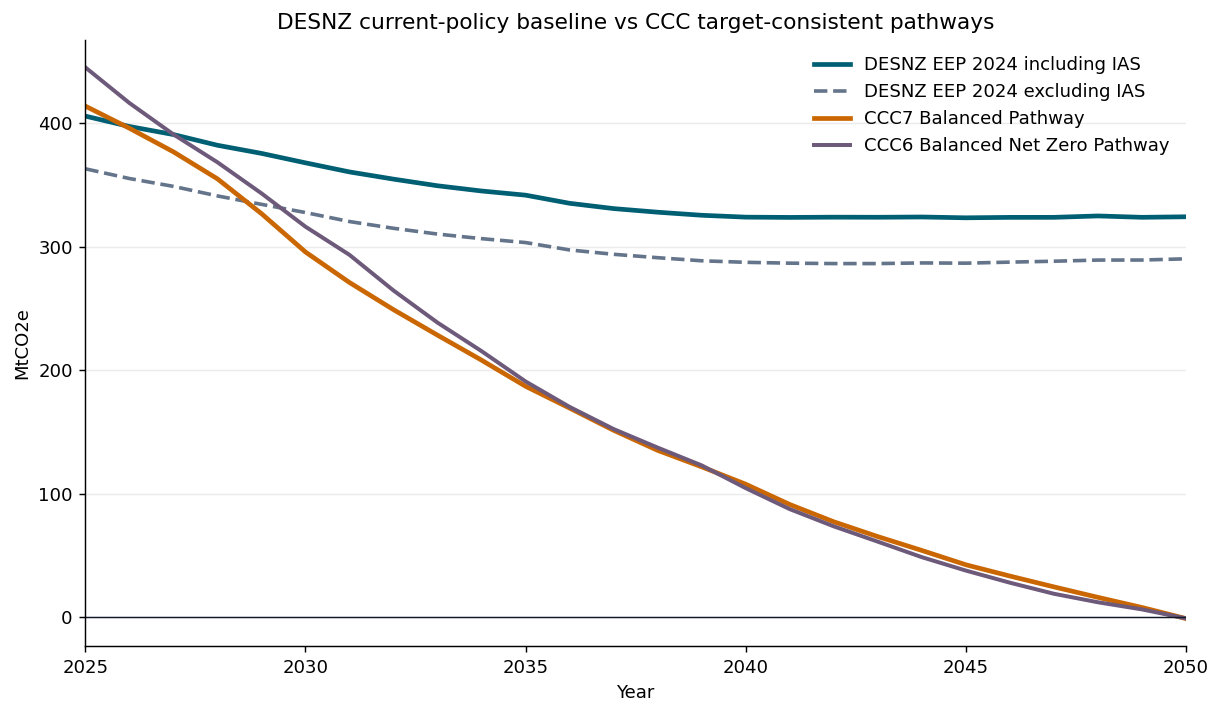

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))

ax.plot(
    annual_comparison["year"],
    annual_comparison["DESNZ_EEP_2024_inc_IAS_MtCO2e"],
    label="DESNZ EEP 2024 including IAS",
    linewidth=2.6,
    color="#005f73",
)
ax.plot(
    annual_comparison["year"],
    annual_comparison["DESNZ_EEP_2024_excl_IAS_MtCO2e"],
    label="DESNZ EEP 2024 excluding IAS",
    linewidth=2.0,
    linestyle="--",
    color="#64748b",
)
ax.plot(
    annual_comparison["year"],
    annual_comparison["CCC7_Balanced_Pathway_MtCO2e"],
    label="CCC7 Balanced Pathway",
    linewidth=2.6,
    color="#ca6702",
)
ax.plot(
    annual_comparison["year"],
    annual_comparison["CCC6_Balanced_Net_Zero_Pathway_MtCO2e"],
    label="CCC6 Balanced Net Zero Pathway",
    linewidth=2.2,
    color="#6d597a",
)

ax.axhline(0, color="#111827", linewidth=0.8)
ax.set_title("DESNZ current-policy baseline vs CCC target-consistent pathways")
ax.set_ylabel("MtCO2e")
ax.set_xlabel("Year")
ax.set_xlim(2025, 2050)
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()

fig.savefig(OUTPUT / "figures" / "desnz_vs_ccc_annual_pathways.png")
fig.savefig(OUTPUT / "figures" / "desnz_vs_ccc_annual_pathways.svg")
plt.show()


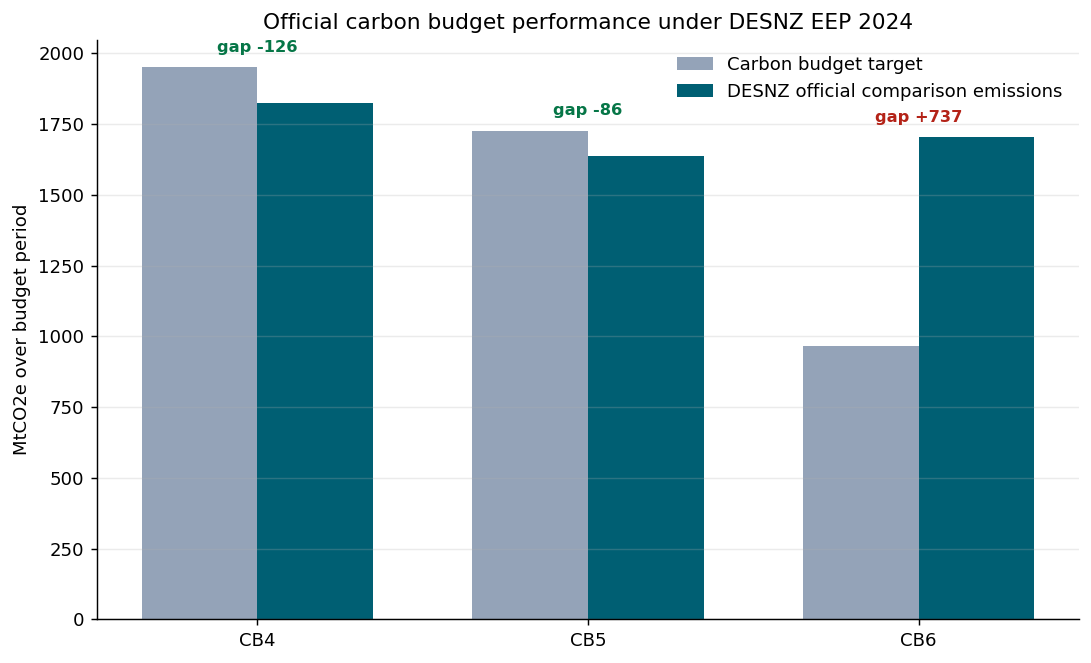

In [16]:
plot_df = carbon_budget_metrics.copy()
x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.bar(
    x - width / 2,
    plot_df["carbon_budget_target_MtCO2e"],
    width,
    label="Carbon budget target",
    color="#94a3b8",
)
ax.bar(
    x + width / 2,
    plot_df["DESNZ_official_comparison_emissions_MtCO2e"],
    width,
    label="DESNZ official comparison emissions",
    color="#005f73",
)

for i, row in plot_df.iterrows():
    gap = row["DESNZ_official_gap_MtCO2e"]
    label = f"gap {gap:+.0f}"
    ymax = max(row["carbon_budget_target_MtCO2e"], row["DESNZ_official_comparison_emissions_MtCO2e"])
    ax.text(
        i,
        ymax + 45,
        label,
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#b42318" if gap > 0 else "#067647",
    )

ax.set_xticks(x)
ax.set_xticklabels(plot_df["period"])
ax.set_ylabel("MtCO2e over budget period")
ax.set_title("Official carbon budget performance under DESNZ EEP 2024")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()

fig.savefig(OUTPUT / "figures" / "carbon_budget_period_comparison.png")
fig.savefig(OUTPUT / "figures" / "carbon_budget_period_comparison.svg")
plt.show()


## 15. Consistency checks

These assertions confirm that the notebook reproduces the current P4-P5 headline values. If they fail, either the source files changed or the extraction logic needs review.


In [17]:
headline_2050_gap = float(
    key_benchmark_years.loc[
        key_benchmark_years["year"] == 2050,
        "gap_inc_IAS_DESNZ_minus_CCC7_MtCO2e",
    ].iloc[0]
)
cb6_official_gap = float(
    carbon_budget_metrics.loc[
        carbon_budget_metrics["period"] == "CB6",
        "DESNZ_official_gap_MtCO2e",
    ].iloc[0]
)

print(f"2050 DESNZ including-IAS vs CCC7 gap: {headline_2050_gap:.1f} MtCO2e")
print(f"CB6 official DESNZ projected gap: {cb6_official_gap:.1f} MtCO2e")

assert abs(headline_2050_gap - 325.398436382106) < 1e-6
assert abs(cb6_official_gap - 737.469408760892) < 1e-6
assert historical_max_abs_diff < 0.01

print("All checks passed.")


2050 DESNZ including-IAS vs CCC7 gap: 325.4 MtCO2e
CB6 official DESNZ projected gap: 737.5 MtCO2e
All checks passed.


## 16. Headline results for writing


In [18]:
summary = pd.Series({
    "Official historical GHG 1990 (MtCO2e)": float(historical_final_ghg.loc[1990]),
    "Official historical GHG 2023 (MtCO2e)": float(historical_final_ghg.loc[2023]),
    "Historical check max absolute difference (MtCO2e)": float(historical_max_abs_diff),
    "DESNZ 2050 excluding IAS (MtCO2e)": float(desnz_excl_ias.loc[2050]),
    "DESNZ 2050 including IAS (MtCO2e)": float(desnz_inc_ias.loc[2050]),
    "CCC7 2050 Balanced Pathway (MtCO2e)": float(ccc7_series.loc[2050]),
    "2050 gap, DESNZ inc IAS minus CCC7 (MtCO2e)": headline_2050_gap,
    "2050 gap, DESNZ inc IAS minus CCC6 (MtCO2e)": float(
        key_benchmark_years.loc[
            key_benchmark_years["year"] == 2050,
            "gap_inc_IAS_DESNZ_minus_CCC6_MtCO2e",
        ].iloc[0]
    ),
    "CB6 official DESNZ projected gap (MtCO2e)": cb6_official_gap,
    "CB6 DESNZ excluding-IAS gap (MtCO2e)": float(
        carbon_budget_metrics.loc[carbon_budget_metrics["period"] == "CB6", "DESNZ_excl_IAS_MtCO2e"].iloc[0]
        - carbon_budget_metrics.loc[carbon_budget_metrics["period"] == "CB6", "carbon_budget_target_MtCO2e"].iloc[0]
    ),
    "2025-2050 cumulative gap, DESNZ inc IAS minus CCC7 (MtCO2e)": float(
        cumulative_gap_metrics.loc[
            cumulative_gap_metrics["gap_basis"] == "DESNZ inc IAS minus CCC7 Balanced Pathway",
            "cumulative_gap_MtCO2e",
        ].iloc[0]
    ),
})

show(summary.round(1).to_frame("value"))


,value
Official historical GHG 1990 (MtCO2e),810.7
Official historical GHG 2023 (MtCO2e),385.0
Historical check max absolute difference (MtCO2e),0.0
DESNZ 2050 excluding IAS (MtCO2e),290.2
DESNZ 2050 including IAS (MtCO2e),324.3
CCC7 2050 Balanced Pathway (MtCO2e),-1.1
"2050 gap, DESNZ inc IAS minus CCC7 (MtCO2e)",325.4
"2050 gap, DESNZ inc IAS minus CCC6 (MtCO2e)",325.3
CB6 official DESNZ projected gap (MtCO2e),737.5
CB6 DESNZ excluding-IAS gap (MtCO2e),546.6
